# 1 Basic example

This notebook runs a basic parametrization of the model.

We simulate an SIR epidemic in a system of M subpopulations.



In [2]:
import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

from EpiCommute import SIRModel

matplotlib.rc('figure', dpi=200)
np.random.seed = 1234

## Inicialización de la metapoblación

En este bloque generamos un ejemplo sintético de una metapoblación.

- Número de subpoblaciones: `M = 20`  
  Define cuántas regiones (nodos) tendrá el sistema.

- Matriz de movilidad: `mobility = np.random.rand(M, M)`  
  Se crea una matriz $M \times M$ con valores aleatorios en \([0,1]\), donde cada entrada:

   $(j, i) $

  representa la intensidad del flujo de personas desde la región $i$ hacia la región $j$.  
  En este ejemplo, la movilidad es completamente aleatoria (no basada en datos reales).

- Tamaños de las subpoblaciones: `subpopulation_sizes = np.random.randint(20, 100, M)`  
  Se asigna a cada región un tamaño poblacional entero aleatorio entre 20 y 100.

---

### Interpretación

- Tenemos $M$ regiones conectadas entre sí.
- Cada región tiene una población distinta.
- La matriz de movilidad define cómo se conectan las regiones mediante flujos de personas.

Este bloque construye la estructura básica sobre la que se simulará la dinámica epidémica.

In [15]:
M = 20    # Number of subpopulations

# Initialize a random mobility matrix
mobility = np.random.rand(M, M)

# Choose random subpopulation sizes
subpopulation_sizes = np.random.randint(20,100,M)

In [8]:
subpopulation_sizes

array([70, 56, 32, 80, 63, 99, 66, 64, 78, 20, 44, 51, 58, 26, 42, 22, 28,
       34, 53, 38])

## Visualización de la red de movilidad

En este bloque construimos y visualizamos una red dirigida que representa la metapoblación:

- **Nodos**: cada nodo corresponde a una subpoblación (región).
- **Tamaño del nodo**: proporcional al tamaño de la población de esa región.
- **Aristas dirigidas (flechas)**: representan los flujos de movilidad entre regiones.
- **Grosor de las aristas**: proporcional a la intensidad del flujo (más grueso = mayor movilidad).

El grafo se construye con `networkx` a partir de la matriz de movilidad, donde cada entrada \( (i, j) \) indica el flujo desde la región \(i\) hacia la región \(j\).

Para facilitar la interpretación visual:
- Se utiliza un layout tipo *spring* para distribuir los nodos en el espacio.
- Los pesos de las aristas se normalizan para escalar su grosor.
- Opcionalmente, se puede aplicar un umbral para mostrar solo las conexiones más relevantes.

Esta visualización ayuda a entender cómo la estructura de movilidad conecta las subpoblaciones y condiciona la propagación de la epidemia.

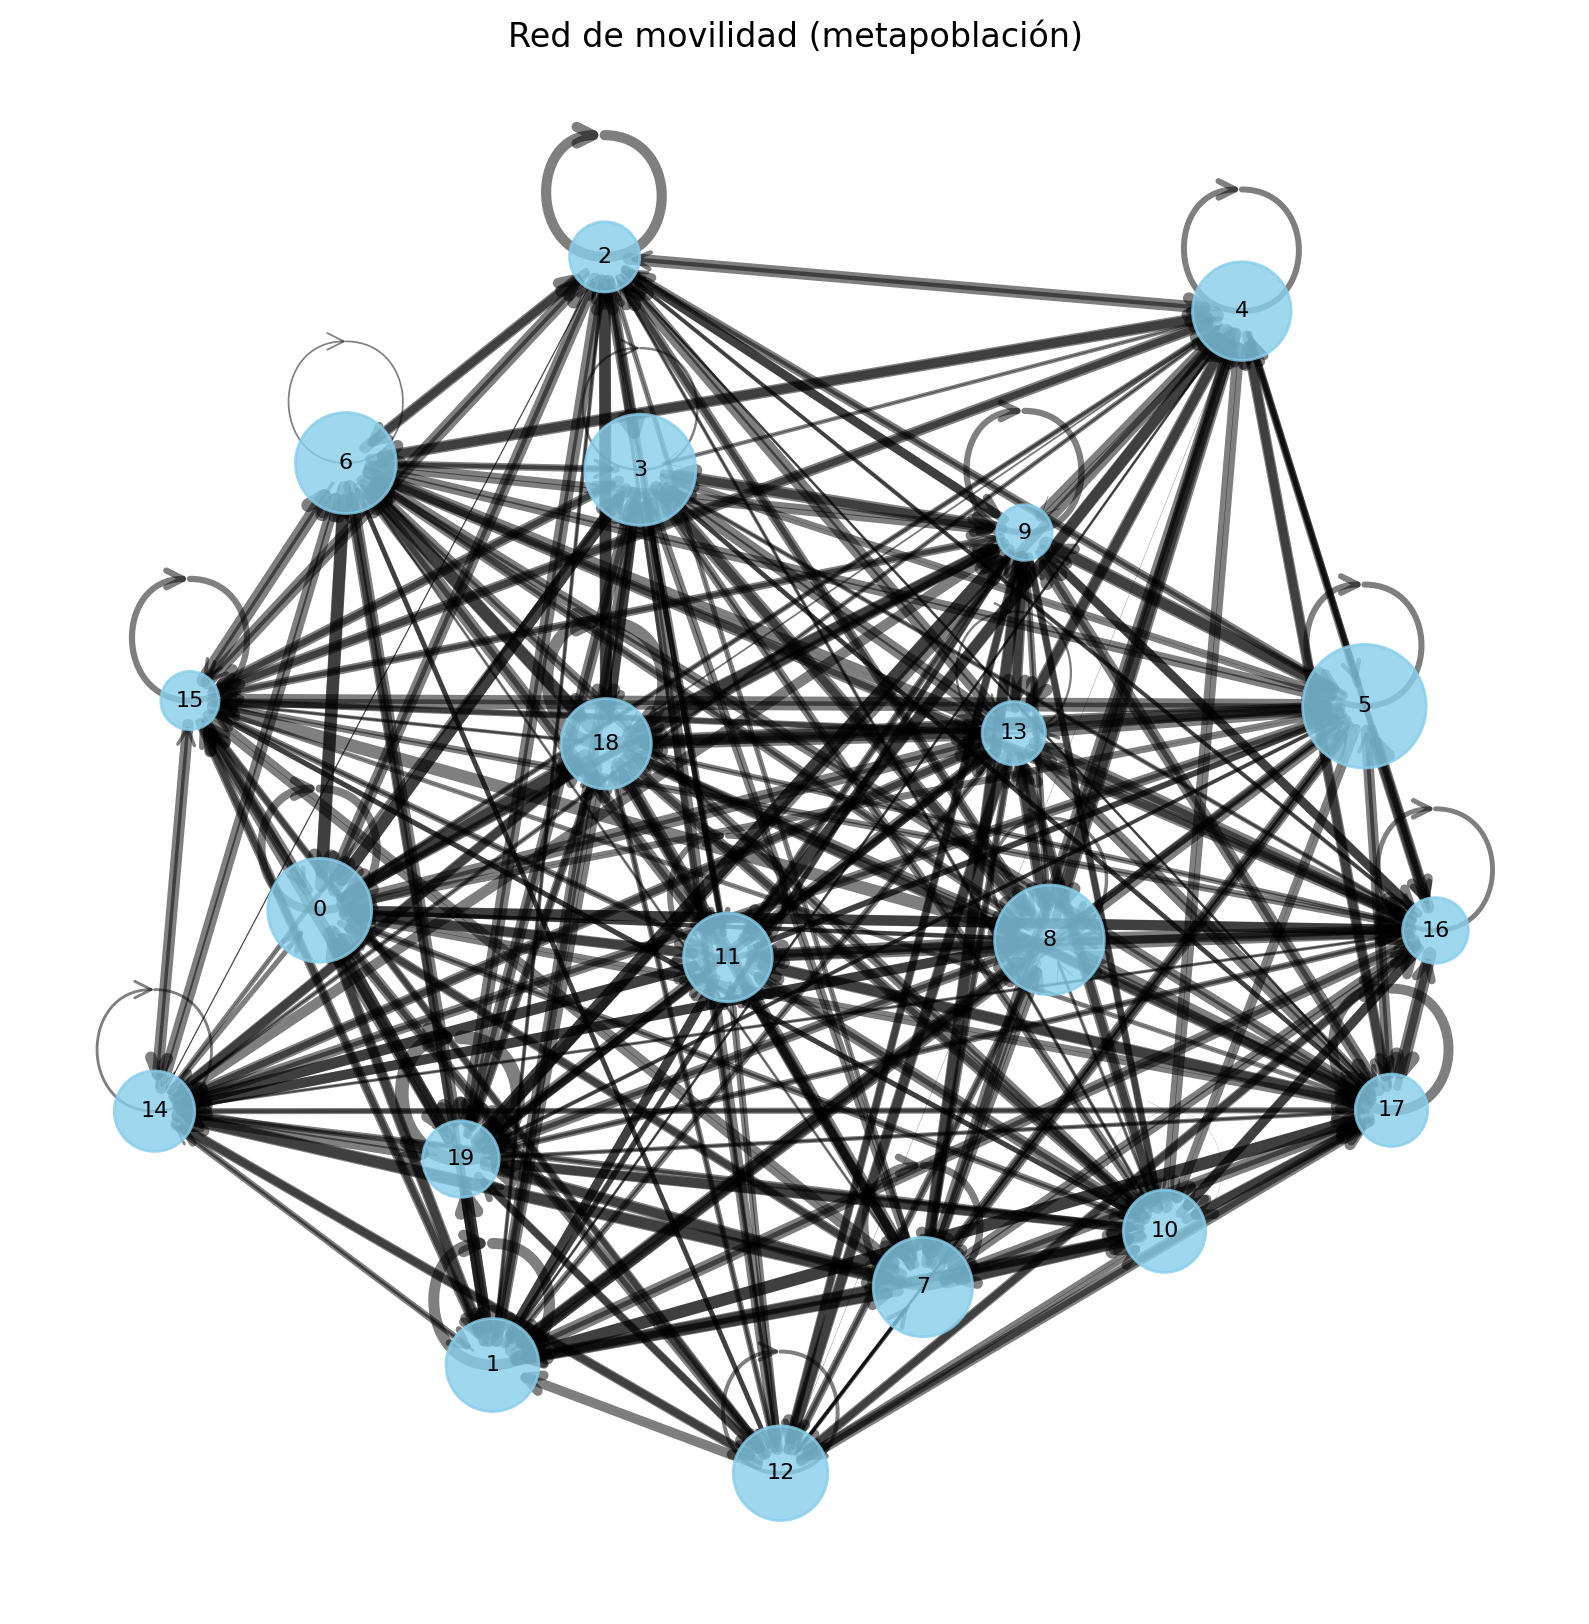

In [7]:
# --- Create directed graph ---
G = nx.DiGraph()

# Add nodes with population attribute
for i in range(M):
    G.add_node(i, population=subpopulation_sizes[i])

# Add edges with mobility weights
for i in range(M):
    for j in range(M):
        if mobility[i, j] > 0:  # you can threshold here if needed
            G.add_edge(i, j, weight=mobility[i, j])

# --- Layout ---
pos = nx.spring_layout(G, seed=42)  # nice spatial layout

# --- Node sizes (scaled) ---
node_sizes = subpopulation_sizes * 20  # adjust scale if needed

# --- Edge widths (scaled) ---
weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
edge_widths = 5 * (weights / weights.max())  # normalize + scale

# --- Draw ---
plt.figure(figsize=(10, 10))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color='skyblue',
    alpha=0.8
)

# Edges
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.5,
    arrows=True,
    arrowsize=15,
    arrowstyle='->'
)

# Labels
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Red de movilidad (metapoblación)")
plt.axis('off')
plt.show()

## Parámetros epidemiológicos e inicialización

En este bloque definimos los parámetros del modelo SIR y las condiciones iniciales de la simulación.

### Parámetros epidemiológicos

- Tasa de infección: `beta = 0.375`  
  Controla la probabilidad de transmisión por contacto.

- Tasa de recuperación: `mu = 1/8`  
  Representa la fracción de individuos infectados que se recuperan por unidad de tiempo (en este caso, un tiempo medio de infección de 8 días).

- Número reproductivo básico: `R0 = beta / mu`  
  Indica el número medio de infecciones secundarias generadas por un individuo infectado en una población completamente susceptible.

---

### Condiciones iniciales

- Número inicial de infectados: `initial_infected = 10`  
  Cantidad de individuos con los que comienza la epidemia.

- Región de inicio: `outbreak_source = 9`  
  Índice de la subpoblación donde se introduce la infección (también puede ser `'random'`).

- Tiempo total de simulación: `T_max = 100`  
  Duración total del experimento *in silico*.

---

### Inicialización del modelo

Se crea una instancia del modelo `SIRModel` utilizando:

- La estructura de movilidad (`mobility`)
- Los tamaños poblacionales (`subpopulation_sizes`)
- Los parámetros epidemiológicos y de simulación

Además:

- `dt` controla el paso de tiempo de la simulación
- `dt_save` define cada cuánto se guardan los resultados
- `VERBOSE=True` permite seguir el progreso de la simulación

Finalmente, se ejecuta la simulación con:

- `model.run_simulation()`

---

### Interpretación

Este bloque define completamente el experimento:

- Qué tan contagiosa es la enfermedad
- Cuánto dura la infección
- Dónde comienza el brote
- Cuánto tiempo se simula

👉 A partir de aquí, el modelo evoluciona dinámicamente la epidemia en la red de subpoblaciones.

In [16]:
########################
# Epidemic parameters
########################

# Infectious rate
beta = 0.375

# Recovery rate (1/days)
mu   = 1.0/8.0 

# Basic reproduction number
R0   = beta / mu 

#########################
# Initial conditions
#########################

# Number of initial infected
initial_infected = 10

# Index of the region where the epidemic starts (accepts 'random')
outbreak_source  = 9

# Total simulation time
T_max = 100 

# Initialize the model
model = SIRModel(
            mobility,
            subpopulation_sizes,
            outbreak_source=outbreak_source, # random outbreak location
            dt=0.1,                          # simulation time interval
            dt_save=1,                       # time interval when to save observables
            I0=initial_infected,             # number of initial infected
            T_max=T_max,                     # Max simulation time
            VERBOSE=True                     # print verbose output
        )

result = model.run_simulation()

region_ids = [f"R{i}" for i in range(M)]

time = result['t']
I = np.array(result['I']) # Infected per patch per time T_max x M
S = np.array(result['S']) # Suceptibles per patch per time T_max x M
R = np.array(result['R']) # Recovered per patch per time T_max x M

S_total = S.sum(axis=1)
I_total = I.sum(axis=1)
R_total = R.sum(axis=1)

Starting Simulation ...
Simulation completed
Time: 0min 2.87s


## Show results

### Epidemic curve

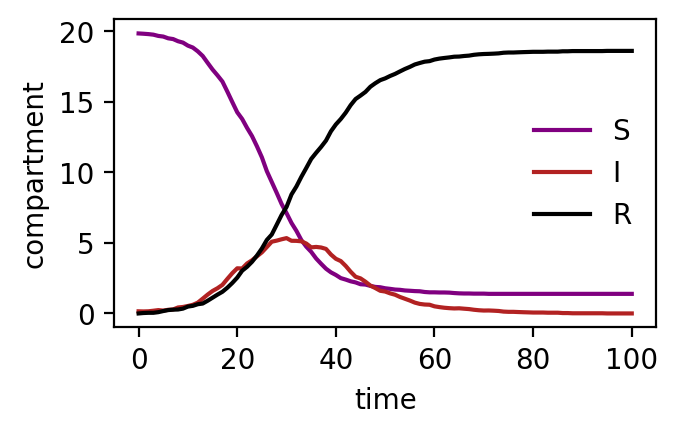

In [17]:
figure = plt.figure(figsize=(3.5,2))
plt.plot(time, S_total, label='S', color='purple')
plt.plot(time, I_total, label='I', color='firebrick')
plt.plot(time, R_total, label='R', color='k')
plt.legend(frameon=False, loc='center right')
plt.xlabel("time")
plt.ylabel("compartment")
plt.show()

## Ejercicio 1 — Infectados por región

Representa el número de individuos infectados a lo largo del tiempo para cada región.

Preguntas:

- ¿Alcanzan todas las regiones el pico al mismo tiempo?
- ¿Qué regiones se infectan primero?
- ¿De qué depende el orden de infección?

In [22]:
I.shape

(101, 20)

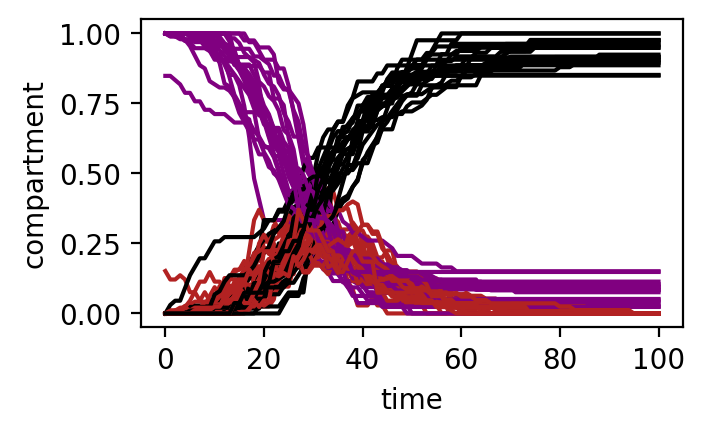

In [20]:
figure = plt.figure(figsize=(3.5,2))


for i in range(M):
    S_i = S[:,i]
    I_i = I[:,i]
    R_i = R[:,i]
    plt.plot(time, S_i, label='S', color='purple')
    plt.plot(time, I_i, label='I', color='firebrick')
    plt.plot(time, R_i, label='R', color='k')


plt.xlabel("time")
plt.ylabel("compartment")
plt.show()

## Ejercicio 2 — De simulación a xarray

Convierte la salida de la simulación en un objeto `xarray.Dataset`.

Sugerencias:

- Dimensiones: `time`, `region`
- Variables: `S`, `I`, `R`

Preguntas:

- ¿Cuáles son las dimensiones del dataset?
- ¿Qué coordenadas puedes definir?
- ¿Qué ventajas tiene esta representación frente a arrays o dataframes?

In [39]:
import xarray as xr

res_ds = xr.Dataset(data_vars={
                        'I':(['time', 'region'], I), 
                        'S':(['time', 'region'], S), 
                        'R': (['time', 'region'], R)}, 
           coords={'time':time, 'region':region_ids})

## Ejercicio 3 — Origen de la epidemia

Modifica la región inicial donde comienza la infección.

Preguntas:

- ¿Cómo cambia la propagación?
- ¿Influye la posición de la región en la red?
- ¿Qué regiones parecen más “centrales”?

# Ejercicios intermedios

## Ejercicio 4 — Origen de la epidemia

Modifica la región inicial donde comienza la infección.

Preguntas:

- ¿Cómo cambia la propagación?
- ¿Influye la posición de la región en la red?
- ¿Qué regiones parecen más “centrales”?

## Ejercicio 5 — Tiempo hasta el pico

Calcula el tiempo en el que cada región alcanza su pico de infectados.

Preguntas:

- ¿Están sincronizadas las regiones?
- ¿Qué factores explican las diferencias?

In [40]:
np.argmax(I_total)
res_ds['I'].argmax('time')

<xarray.DataArray 'I' (region: 20)> Size: 160B
array([29, 27, 34, 19, 25, 33, 25, 29, 38, 34, 34, 40, 32, 23, 38, 30, 31,
       29, 35, 27])
Coordinates:
  * region   (region) <U3 240B 'R0' 'R1' 'R2' 'R3' ... 'R16' 'R17' 'R18' 'R19'

# EJERCICIOS AVANZADOS

## Ejercicio 6 — Relación con la movilidad

Analiza qué regiones:

- se infectan antes
- tienen mayor número de casos

Hipótesis:

- regiones con mayor conectividad o movilidad reciben antes la infección

¿Se confirma en la simulación?

## Ejercicio 7 — Relación con la movilidad

Analiza qué regiones:

- se infectan antes
- tienen mayor número de casos

Hipótesis:

- regiones con mayor conectividad o movilidad reciben antes la infección

¿Se confirma en la simulación?

## Ejercicio 8 — Intervención

Reduce la movilidad entre regiones.

Preguntas:

- ¿Cómo cambia el pico de la epidemia?
- ¿Se retrasa la propagación?
- ¿Se reduce el número total de infectados?

## Ejercicio 9 — Sensibilidad

Modifica ligeramente el parámetro beta.

Preguntas:

- ¿El sistema es sensible a pequeños cambios?
- ¿Cambian mucho los resultados?

## Ejercicio — Exploración del modelo

Simula el modelo para distintos valores de beta.

Representa:

- el pico de infectados en función de beta

Preguntas:

- ¿Cómo cambia el comportamiento del sistema?
- ¿Existe un umbral?